In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/content/bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df_clean = df.copy()

print(df_clean.shape)

(45211, 17)


In [6]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical")
print(numerical_cols)

print("\nCategorical")
print(categorical_cols)

Numerical
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


Missing Value Audit

In [4]:
missing_table = (
    df_clean
    .isna()
    .sum()
    .reset_index()
)

missing_table.columns = [
    "feature",
    "missing_count"
]

missing_table["missing_pct"] = (
    missing_table["missing_count"]
    / len(df_clean)
)

missing_table.sort_values(
    "missing_pct",
    ascending=False
)

,feature,missing_count,missing_pct
0,age,0,0.0
1,job,0,0.0
2,marital,0,0.0
3,education,0,0.0
4,default,0,0.0
5,balance,0,0.0
6,housing,0,0.0
7,loan,0,0.0
8,contact,0,0.0
9,day,0,0.0


No explicit missing values were observed.

However, several categorical variables use
'unknown' as a placeholder for missing information.

Audit Unknown Categories

In [7]:
unknown_summary = []

for col in categorical_cols:

    unknown_pct = (
        (df_clean[col] == "unknown")
        .mean()
    )

    if unknown_pct > 0:

        unknown_summary.append([
            col,
            unknown_pct
        ])

unknown_summary = pd.DataFrame(
    unknown_summary,
    columns=["feature","unknown_pct"]
)

unknown_summary.sort_values(
    "unknown_pct",
    ascending=False
)

,feature,unknown_pct
3,poutcome,0.817478
2,contact,0.287983
1,education,0.041074
0,job,0.006370


In [8]:
for col in categorical_cols:

    if "unknown" in df_clean[col].unique():

        print(col)

        display(
            pd.crosstab(
                df_clean[col],
                df_clean["y"],
                normalize="index"
            )
        )

job


y,no,yes
job,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


education


y,no,yes
education,,
primary,0.913735,0.086265
secondary,0.894406,0.105594
tertiary,0.849936,0.150064
unknown,0.864297,0.135703


contact


y,no,yes
contact,,
cellular,0.850811,0.149189
telephone,0.865795,0.134205
unknown,0.959293,0.040707


poutcome


y,no,yes
poutcome,,
failure,0.873903,0.126097
other,0.833152,0.166848
success,0.352747,0.647253
unknown,0.908385,0.091615


Leakage Review

In [9]:
df_clean.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


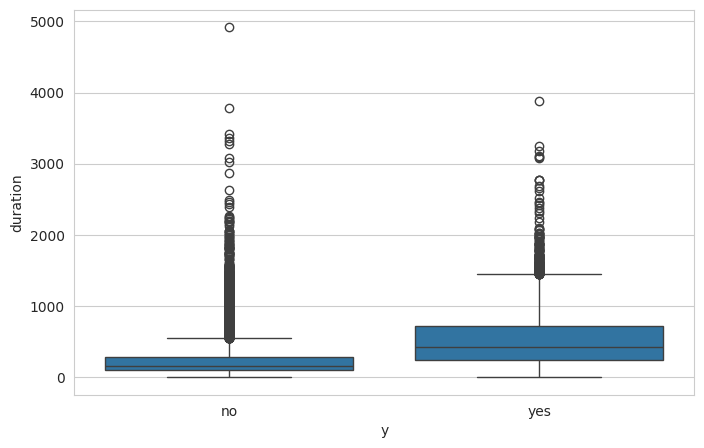

In [10]:
sns.boxplot(
    data=df_clean,
    x="y",
    y="duration"
)

plt.show()

In [11]:
LEAKAGE_FEATURES = [
    "duration"
]

In [12]:
df_clean = df_clean.drop(
    columns=LEAKAGE_FEATURES
)

Duration was excluded because it is only available after
the call is completed and would not be known at scoring time.

Numerical Skewness Treatment

In [13]:
num_cols_clean = df_clean.select_dtypes(
    include=np.number
).columns

pd.DataFrame({
    "skewness": df_clean[num_cols_clean].skew()
}).sort_values(
    "skewness",
    ascending=False
)

,skewness
previous,41.846454
balance,8.360308
campaign,4.898650
pdays,2.615715
age,0.684818
day,0.093079


In [14]:
skewed_features = [
    col
    for col in num_cols_clean
    if abs(df_clean[col].skew()) > 1
]

skewed_features

['balance', 'campaign', 'pdays', 'previous']

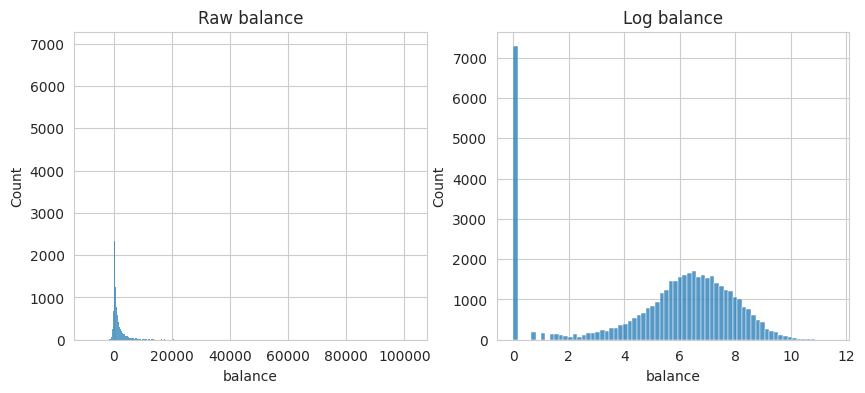

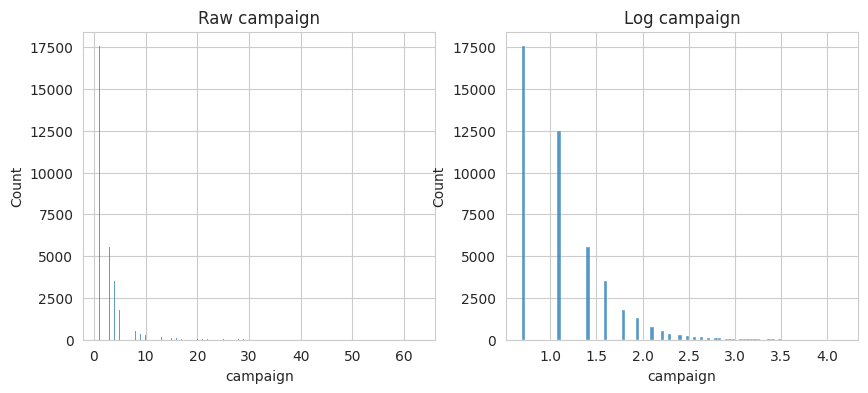

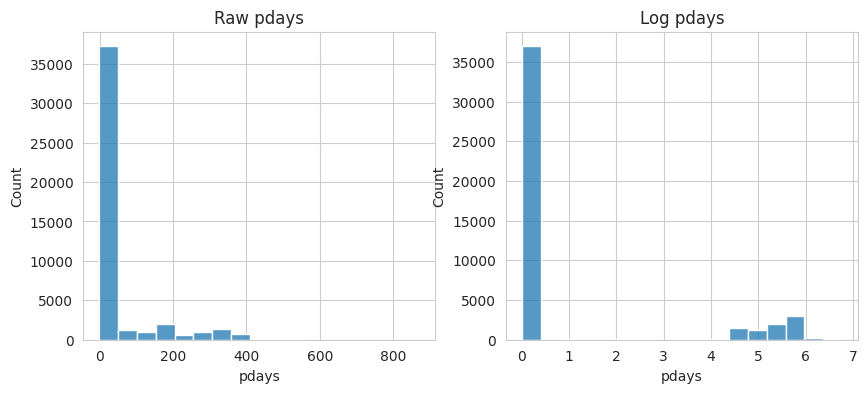

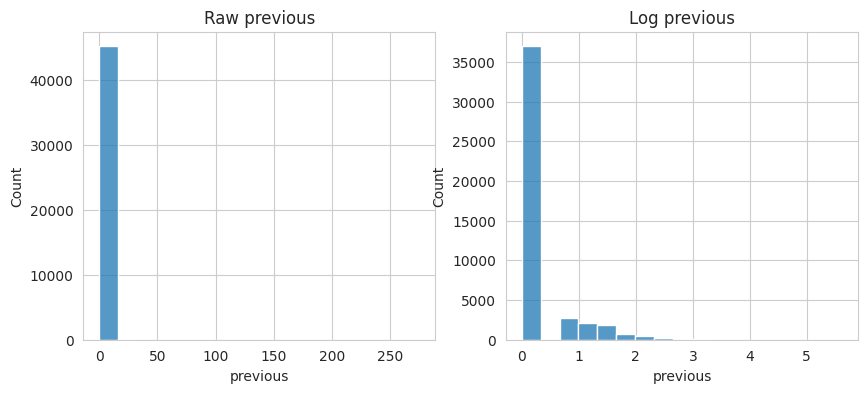

In [15]:
for col in skewed_features:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df_clean[col])

    plt.title(f"Raw {col}")

    plt.subplot(1,2,2)

    sns.histplot(
        np.log1p(
            np.maximum(df_clean[col],0)
        )
    )

    plt.title(f"Log {col}")

    plt.show()

No aggressive outlier removal was applied.

Potential transformations will be evaluated
during feature engineering.

Target Encoding Check

In [16]:
df_clean["target"] = (
    df_clean["y"]
    .map({
        "yes":1,
        "no":0
    })
)

In [17]:
df_clean["target"].value_counts()

,count
target,
0,39922
1,5289


In [18]:
duplicates = df_clean.duplicated().sum()

print(
    f"Duplicate rows: {duplicates}"
)

Duplicate rows: 16


In [19]:
df_clean = df_clean.drop_duplicates()

In [20]:
cleaning_report = {
    "rows": len(df_clean),
    "columns": len(df_clean.columns),
    "duplicates_removed": duplicates,
    "leakage_features_removed": LEAKAGE_FEATURES,
}

cleaning_report

{'rows': 45195,
 'columns': 17,
 'duplicates_removed': np.int64(16),
 'leakage_features_removed': ['duration']}

## Data Cleaning Summary

1. No explicit missing values were detected.

2. 'Unknown' categories were retained because they may contain predictive information.

3. Duplicate observations were checked and removed if present.

4. No aggressive outlier removal was applied because extreme values may represent valid customer behavior.

5. The feature 'duration' was removed due to target leakage concerns.

6. Target variable was converted into binary format for modeling.

The resulting dataset is considered modeling-ready and will be used for feature engineering and train-validation-test splitting.

# 2. Feature Engineering

In [21]:
df_fe = df_clean.copy()

print(df_fe.shape)

(45195, 17)


1. Age Bucket

In [22]:
df_fe["age_bucket"] = pd.cut(
    df_fe["age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [23]:
pd.crosstab(
    df_fe["age_bucket"],
    df_fe["y"],
    normalize="index"
)

y,no,yes
age_bucket,,
18-25,0.763416,0.236584
26-35,0.879892,0.120108
36-45,0.906099,0.093901
46-55,0.906443,0.093557
56-65,0.858727,0.141273
65+,0.573901,0.426099


2. Contact Before Flag

In [24]:
df_fe["contacted_before"] = np.where(
    df_fe["pdays"] > 0,
    1,
    0
)

In [25]:
pd.crosstab(
    df_fe["contacted_before"],
    df_fe["y"],
    normalize="index"
)

y,no,yes
contacted_before,,
0,0.908387,0.091613
1,0.769287,0.230713


3. Previous Campaign Success Flag

In [26]:
df_fe["prev_success"] = (
    df_fe["poutcome"] == "success"
).astype(int)

In [27]:
pd.crosstab(
    df_fe["prev_success"],
    df_fe["y"],
    normalize="index"
)

y,no,yes
prev_success,,
0,0.901314,0.098686
1,0.352747,0.647253


4. Balance Segmentation

In [28]:
df_fe["balance_segment"] = pd.qcut(
    df_fe["balance"],
    q=5,
    duplicates="drop"
)

In [29]:
pd.crosstab(
    df_fe["balance_segment"],
    df_fe["y"],
    normalize="index"
)

y,no,yes
balance_segment,,
"(-8019.001, 23.0]",0.930531,0.069469
"(23.0, 272.0]",0.899499,0.100501
"(272.0, 702.0]",0.883044,0.116956
"(702.0, 1860.2]",0.865227,0.134773
"(1860.2, 102127.0]",0.836265,0.163735


5. Campaign Intensity

Business Hypothesis: Too much call leads to low conversion rate

In [30]:
df_fe["campaign_bucket"] = pd.cut(
    df_fe["campaign"],
    bins=[0,1,2,5,10,100],
    labels=[
        "1",
        "2",
        "3-5",
        "6-10",
        "10+"
    ]
)

In [31]:
pd.crosstab(
    df_fe["campaign_bucket"],
    df_fe["y"],
    normalize="index"
)

y,no,yes
campaign_bucket,,
1,0.853983,0.146017
2,0.887893,0.112107
3-5,0.900602,0.099398
6-10,0.934769,0.065231
10+,0.960702,0.039298


6. Log Balance

In [32]:
df_fe["balance_log"] = np.log1p(
    np.maximum(df_fe["balance"], 0)
)

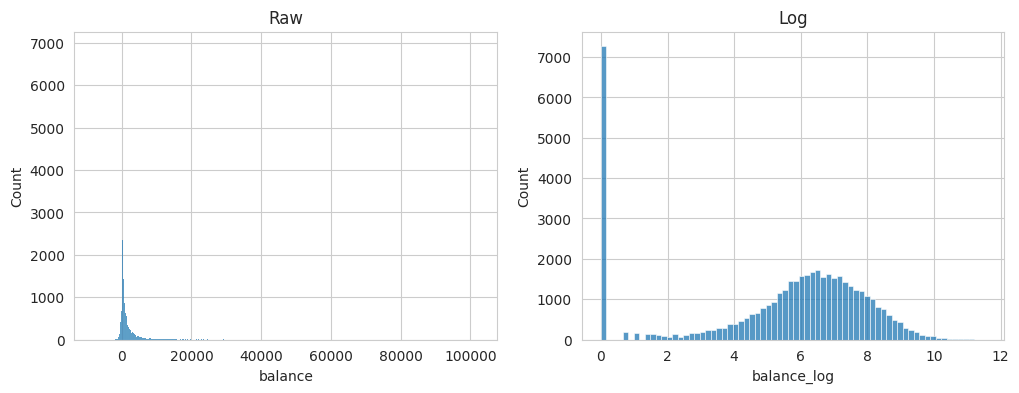

In [33]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df_fe["balance"], ax=ax[0])
ax[0].set_title("Raw")

sns.histplot(df_fe["balance_log"], ax=ax[1])
ax[1].set_title("Log")

plt.show()

7. Month Cycle

In [34]:
df_fe['month'].head()

,month
0,may
1,may
2,may
3,may
4,may


In [35]:
month_map = {
    "jan":1,
    "feb":2,
    "mar":3,
    "apr":4,
    "may":5,
    "jun":6,
    "jul":7,
    "aug":8,
    "sep":9,
    "oct":10,
    "nov":11,
    "dec":12
}

df_fe["month_num"] = (
    df_fe["month"]
    .map(month_map)
)

In [36]:
df_fe["month_sin"] = np.sin(
    2*np.pi*df_fe["month_num"]/12
)

df_fe["month_cos"] = np.cos(
    2*np.pi*df_fe["month_num"]/12
)

Feature Inventory

In [37]:
feature_inventory = pd.DataFrame({
    "feature": df_fe.columns
})

feature_inventory

,feature
0,age
1,job
2,marital
3,education
4,default
5,balance
6,housing
7,loan
8,contact
9,day


### Feature Engineering Summary

Created additional business-oriented features:

- age_bucket
- contacted_before
- prev_success
- has_any_loan
- balance_segment
- campaign_bucket
- balance_log
- month_sin
- month_cos

These features were designed to capture non-linear customer behavior and historical interaction patterns that may influence subscription propensity.

# Train / Valid / Test split

In [39]:
TARGET = "target"
drop_cols = [
    "y"
]

In [40]:
X = df_fe.drop(columns=drop_cols + [TARGET])

y = df_fe[TARGET]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

In [46]:
X_train_full.shape

(38415, 24)

In [47]:
X_test.shape

(6780, 24)

In [48]:
X_train_full.to_csv(
    "X_train_full.csv",
    index=False
)

In [49]:
y_train_full.to_frame().to_csv(
    "y_train_full.csv",
    index=False
)

In [50]:
X_test.to_csv(
    "X_test.csv",
    index=False
)

In [51]:
y_test.to_frame().to_csv(
    "y_test.csv",
    index=False
)